In [9]:
import os
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [2]:
def hamming(x, y):
    return sum(i != j for i, j in zip(x, y))

In [4]:
! pwd
# ls ../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/clIDs/SK_B*

/Users/alyulina/Projects/Cancer/Code


In [5]:
# looking at the spike-in sequencing + panc2 
# were the clIDs correctly inferred?

In [208]:
# cell line IDs
clIDs = ['GATC', 'TGCT', 'TGTG', 'AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['Spike-in 1', 'Spike-in 2', 'Spike-in 3', 'mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
clID_dict['other'] = 'other'


In [209]:
matched_to_clIDs = {}
total_n_reads = {}

samples = ['A', 'B', 'C', 'D']
samples_clIDs = {'A': 'GATC', 'B': 'TGCT', 'C': 'TGTG', 'D': 'AGCA'}

for sample in samples:
    matched_to_clIDs_sample = []
    
    for i in clIDs:
        path = '../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/clIDs/SK_' + sample + '_' + i + '_bc_extracted.txt'
        if os.path.exists(path) == False:
            matched_to_clIDs_sample.append([i, -1, 0])
            continue
        
        with open(path, 'r') as f:
            lines = f.readlines()
            matched_to_clIDs_sample.append([i, hamming(i, samples_clIDs.get(sample)), len(lines)])
        
        
    with open('../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/clIDs/SK_' + sample + '_failed_clIDs.txt', 'r') as f:
        lines = f.readlines()
        matched_to_clIDs_sample.append(['other', -1, len(lines)])

    matched_to_clIDs_sample = sorted(matched_to_clIDs_sample, key=lambda x: x[-1], reverse=True)   
    matched_to_clIDs[sample] = matched_to_clIDs_sample
    
    total_n_reads[sample] = sum([x[-1] for x in matched_to_clIDs_sample])
        

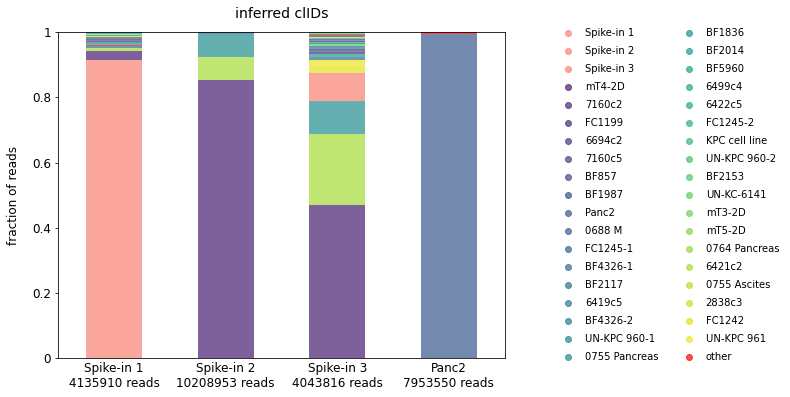

In [277]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs)), 
                                       cmap=plt.get_cmap('viridis'))

colors = dict(zip(clIDs, [viridis.to_rgba(i) for i in range(len(clIDs))]))
colors['other'] = matplotlib.colors.to_rgba('red')
colors['GATC'] = matplotlib.colors.to_rgba('salmon')
colors['TGCT'] = matplotlib.colors.to_rgba('salmon')
colors['TGTG'] = matplotlib.colors.to_rgba('salmon')

plt.figure(figsize=(8, 6))

# making legend:
for i in colors.keys():
    plt.scatter(0, 10, label=clID_dict[i].replace('_', ' '), color=colors[i], alpha=0.7)

plt.bar([1, 2, 3, 4], [matched_to_clIDs[i][0][-1] / total_n_reads[i] for i in samples], width=0.5,
        color=[colors.get(matched_to_clIDs[i][0][0]) for i in samples], alpha=0.7)

for j in range(1, len(clIDs) + 1):
    
    plt.bar([1, 2, 3, 4], [matched_to_clIDs[i][j][-1] / total_n_reads[i] for i in samples], width=0.5,
            bottom=[sum([matched_to_clIDs['A'][k][-1] / total_n_reads['A'] for k in range(0, j)]),
                    sum([matched_to_clIDs['B'][k][-1] / total_n_reads['B'] for k in range(0, j)]),
                    sum([matched_to_clIDs['C'][k][-1] / total_n_reads['C'] for k in range(0, j)]),
                    sum([matched_to_clIDs['D'][k][-1] / total_n_reads['D'] for k in range(0, j)])],
            color=[colors.get(matched_to_clIDs[i][j][0]) for i in samples], alpha=0.7)
    
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], ['0', '0.2', '0.4', '0.6', '0.8', '1'], fontsize=12)

plt.xticks([1, 2, 3, 4], ['Spike-in 1\n' + str(total_n_reads['A']) + ' reads', 
                          'Spike-in 2\n' + str(total_n_reads['B']) + ' reads', 
                          'Spike-in 3\n' + str(total_n_reads['C']) + ' reads', 
                          'Panc2\n' + str(total_n_reads['D']) + ' reads'], fontsize=12)
plt.tick_params(axis='x', length = 0)

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=0.8, bbox_to_anchor=(1.1, 1.04));

plt.title('inferred clIDs', fontsize=14, pad=14)
plt.ylabel('fraction of reads', fontsize=12, labelpad=12)


plt.ylim(0, 1)
plt.xlim(0.5, 4.5)

# plt.savefig('inferred_clIDs_bar_plot.png', dpi=300, bbox_inches='tight')   

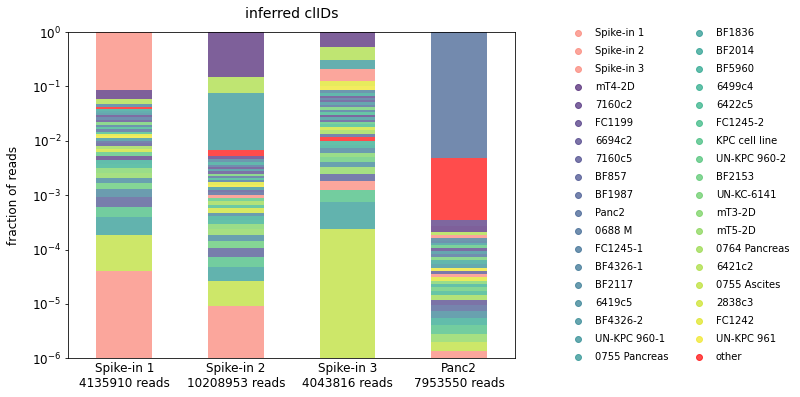

In [276]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs)), 
                                       cmap=plt.get_cmap('viridis'))

colors = dict(zip(clIDs, [viridis.to_rgba(i) for i in range(len(clIDs))]))
colors['other'] = matplotlib.colors.to_rgba('red')
colors['GATC'] = matplotlib.colors.to_rgba('salmon')
colors['TGCT'] = matplotlib.colors.to_rgba('salmon')
colors['TGTG'] = matplotlib.colors.to_rgba('salmon')

plt.figure(figsize=(8, 6))

# making legend:
for i in colors.keys():
    plt.scatter(0, 10, label=clID_dict[i].replace('_', ' '), color=colors[i], alpha=0.7)

plt.bar([1, 2, 3, 4], [-matched_to_clIDs[i][0][-1] / total_n_reads[i] for i in samples], width=0.5,
        bottom=1,
        color=[colors.get(matched_to_clIDs[i][0][0]) for i in samples], alpha=0.7)

for j in range(1, len(clIDs) + 1):
    
    plt.bar([1, 2, 3, 4], [- matched_to_clIDs[i][j][-1] / total_n_reads[i] for i in samples], width=0.5,
            bottom=[1 - sum([matched_to_clIDs['A'][k][-1] / total_n_reads['A'] for k in range(0, j)]),
                    1 - sum([matched_to_clIDs['B'][k][-1] / total_n_reads['B'] for k in range(0, j)]),
                    1 - sum([matched_to_clIDs['C'][k][-1] / total_n_reads['C'] for k in range(0, j)]),
                    1 - sum([matched_to_clIDs['D'][k][-1] / total_n_reads['D'] for k in range(0, j)])],
            color=[colors.get(matched_to_clIDs[i][j][0]) for i in samples], alpha=0.7)

plt.yticks(fontsize=12)

plt.xticks([1, 2, 3, 4], ['Spike-in 1\n' + str(total_n_reads['A']) + ' reads', 
                          'Spike-in 2\n' + str(total_n_reads['B']) + ' reads', 
                          'Spike-in 3\n' + str(total_n_reads['C']) + ' reads', 
                          'Panc2\n' + str(total_n_reads['D']) + ' reads'], fontsize=12)
plt.tick_params(axis='x', length = 0)

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=0.8, bbox_to_anchor=(1.1, 1.04));

plt.title('inferred clIDs', fontsize=14, pad=14)
plt.ylabel('fraction of reads', fontsize=12, labelpad=12)

plt.yscale('log'); plt.minorticks_off()
plt.ylim(1e-6, 1);
plt.xlim(0.5, 4.5);

# plt.savefig('inferred_clIDs_bar_plot_log.png', dpi=300, bbox_inches='tight') 

In [288]:
with open('../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/clIDs/SK_' + 'A' + '_failed_clIDs.txt', 'r') as f:
    A_failed_clIDs_hamming = [hamming(x.split()[1], samples_clIDs.get('A')) for x in f.readlines()]


In [267]:
A_failed_clIDs_hamming_counts = [(x,  A_failed_clIDs_hamming.count(x)) for x in set( A_failed_clIDs_hamming)]

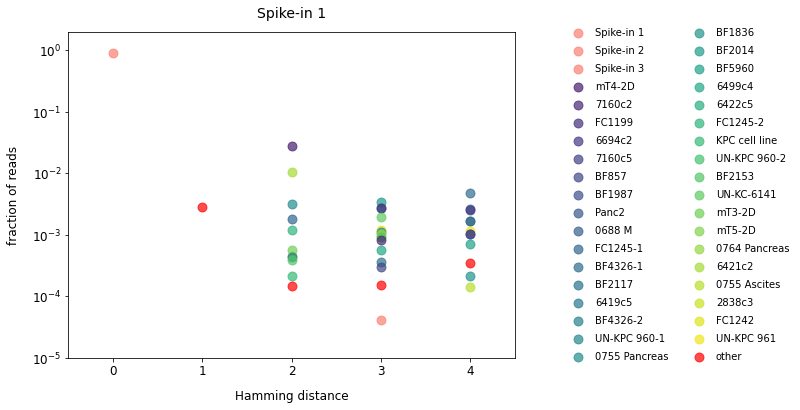

In [286]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs)), 
                                       cmap=plt.get_cmap('viridis'))

colors = dict(zip(clIDs, [viridis.to_rgba(i) for i in range(len(clIDs))]))
colors['other'] = matplotlib.colors.to_rgba('red')
colors['GATC'] = matplotlib.colors.to_rgba('salmon')
colors['TGCT'] = matplotlib.colors.to_rgba('salmon')
colors['TGTG'] = matplotlib.colors.to_rgba('salmon')

plt.figure(figsize=(8, 6))

# making legend:
for i in colors.keys():
    plt.scatter(0, 10, label=clID_dict[i].replace('_', ' '), s=80, color=colors[i], alpha=0.7)

for i in matched_to_clIDs['A']:
    if i[1] == -1:
        continue
    plt.scatter(i[1], i[-1] / total_n_reads['A'], color=colors[i[0]], s=80, alpha=0.7)
    
for i in A_failed_clIDs_hamming_counts:
    plt.scatter(i[0], i[1] / total_n_reads['A'], color='red', s=80, alpha=0.7)
    
plt.yticks(fontsize=12);
plt.xticks(fontsize=12);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=0.8, bbox_to_anchor=(1.1, 1.04));

plt.ylabel('fraction of reads', fontsize=12, labelpad=12)
plt.xlabel('Hamming distance', fontsize=12, labelpad=12)
plt.title('Spike-in 1', fontsize=14, pad=14)

plt.yscale('log'); plt.minorticks_off()
plt.ylim(1e-5, 2);
plt.xlim(-0.5, 4.5);

#plt.savefig('spike-in-1_hamming_distance.png', dpi=300, bbox_inches='tight') 

In [289]:
with open('../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/clIDs/SK_' + 'D' + '_failed_clIDs.txt', 'r') as f:
    D_failed_clIDs_hamming = [hamming(x.split()[1], samples_clIDs.get('D')) for x in f.readlines()]


In [290]:
D_failed_clIDs_hamming_counts = [(x,  D_failed_clIDs_hamming.count(x)) for x in set( D_failed_clIDs_hamming)]

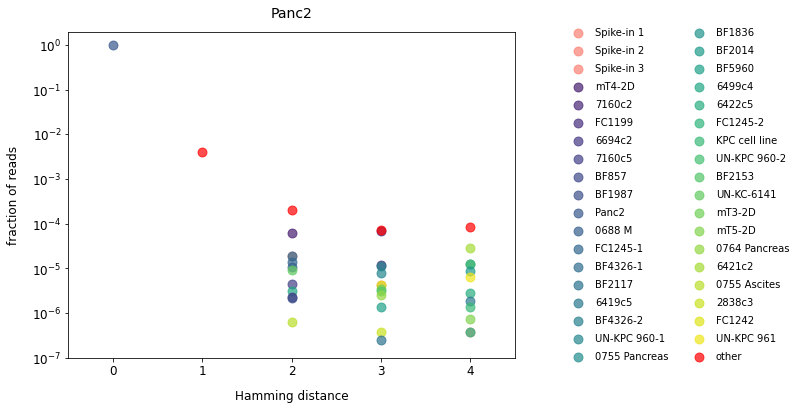

In [295]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(clIDs)), 
                                       cmap=plt.get_cmap('viridis'))

colors = dict(zip(clIDs, [viridis.to_rgba(i) for i in range(len(clIDs))]))
colors['other'] = matplotlib.colors.to_rgba('red')
colors['GATC'] = matplotlib.colors.to_rgba('salmon')
colors['TGCT'] = matplotlib.colors.to_rgba('salmon')
colors['TGTG'] = matplotlib.colors.to_rgba('salmon')

plt.figure(figsize=(8, 6))

# making legend:
for i in colors.keys():
    plt.scatter(0, 10, label=clID_dict[i].replace('_', ' '), s=80, color=colors[i], alpha=0.7)

for i in matched_to_clIDs['D']:
    if i[1] == -1:
        continue
    plt.scatter(i[1], i[-1] / total_n_reads['D'], color=colors[i[0]], s=80, alpha=0.7)
    
for i in D_failed_clIDs_hamming_counts:
    plt.scatter(i[0], i[1] / total_n_reads['D'], color='red', s=80, alpha=0.7)
    
plt.yticks(fontsize=12);
plt.xticks(fontsize=12);

plt.legend(frameon=False, ncol=2, handletextpad=0.7, labelspacing=0.8, bbox_to_anchor=(1.1, 1.04));

plt.ylabel('fraction of reads', fontsize=12, labelpad=12)
plt.xlabel('Hamming distance', fontsize=12, labelpad=12)
plt.title('Panc2', fontsize=14, pad=14)

plt.yscale('log'); plt.minorticks_off()
plt.ylim(1e-7, 2);
plt.xlim(-0.5, 4.5);

# plt.savefig('panc2_hamming_distance.png', dpi=300, bbox_inches='tight') 

In [306]:
sample_clID_counts = [] # a list of dictionaries for each sample

for i, sample in enumerate(['A', 'D']):
    
    sample_clID_counts.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_26.04.2023_X202SC23040899-Z01-F001/SK_' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [390]:
bc_counts_A = [x[-1] for x in sample_clID_counts[0][samples_clIDs['A']]] # n of reads for each bc
bc_fracs_A = [x[-1] / total_n_reads['A'] for x in sample_clID_counts[0][samples_clIDs['A']]] # n of reads for each bc

bc_counts_D = [x[-1] for x in sample_clID_counts[1][samples_clIDs['D']]] # n of reads for each bc
bc_fracs_D = [x[-1] / total_n_reads['D'] for x in sample_clID_counts[1][samples_clIDs['D']]] # n of reads for each bc

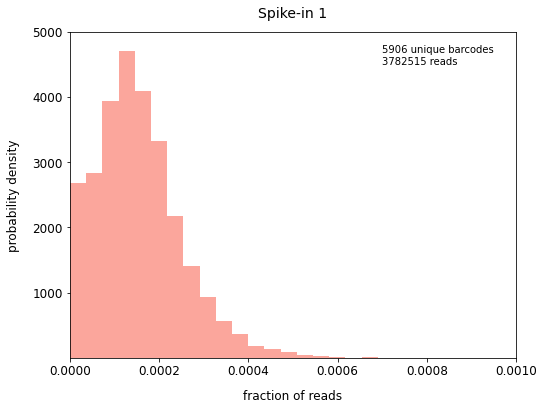

In [392]:
plt.figure(figsize=(8, 6))

plt.hist(bc_fracs_A, density=True, bins=25, color=colors[samples_clIDs['A']], alpha=0.7)

plt.text(0.0007, 4500, str(len(bc_counts_A)) + ' unique barcodes\n' + str(sum(bc_counts_A)) + ' reads')

#plt.yticks([], []);
plt.xticks(fontsize=12);
plt.xlim(0, 0.001)

plt.yticks(fontsize=12);
plt.ylim(2, 5000)

plt.ylabel('probability density', fontsize=12, labelpad=12)
plt.xlabel('fraction of reads', fontsize=12, labelpad=12)
plt.title('Spike-in 1', fontsize=14, pad=14)

# plt.savefig('spike-in1_bc_distr_26.04.png', dpi=300, bbox_inches='tight') 

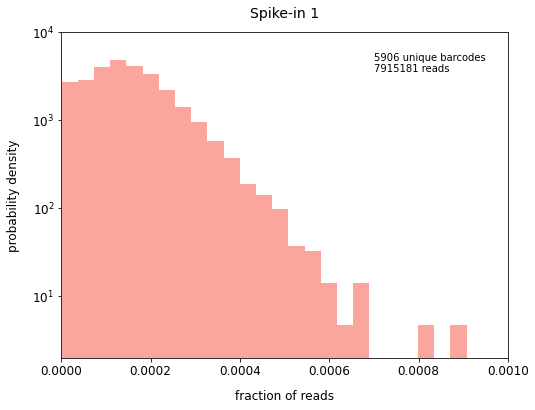

In [393]:
plt.figure(figsize=(8, 6))

plt.hist(bc_fracs_A, density=True, bins=25, color=colors[samples_clIDs['A']], alpha=0.7)

plt.text(0.0007, 3500, str(len(bc_counts_A)) + ' unique barcodes\n' + str(sum(bc_counts_D)) + ' reads')

plt.yscale('log'); plt.minorticks_off()

plt.xticks(fontsize=12);
plt.xlim(0, 0.001)

plt.yticks(fontsize=12);
plt.ylim(2, 10000)

plt.ylabel('probability density', fontsize=12, labelpad=12)
plt.xlabel('fraction of reads', fontsize=12, labelpad=12)
plt.title('Spike-in 1', fontsize=14, pad=14)

# plt.savefig('spike-in1_bc_distr_26.04_log.png', dpi=300, bbox_inches='tight') 

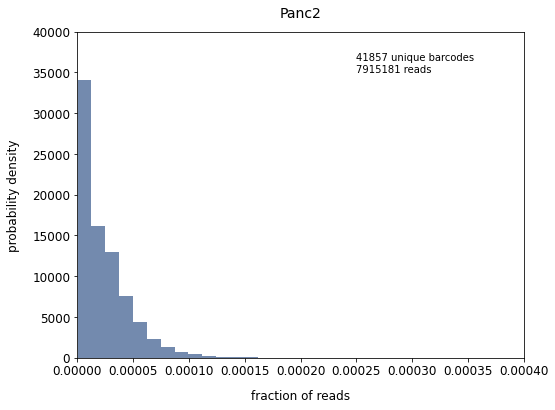

In [420]:
plt.figure(figsize=(8, 6))

plt.hist(bc_fracs_D, density=True, bins=25, color=colors[samples_clIDs['D']], alpha=0.7)

plt.text(0.00025, 35000, str(len(bc_counts_D)) + ' unique barcodes\n' + str(sum(bc_counts_D)) + ' reads')

#plt.yticks([], []);
plt.xticks(fontsize=12);
plt.xlim(0, 0.0004)

plt.yticks(fontsize=12);
plt.ylim(0, 40000)

plt.ylabel('probability density', fontsize=12, labelpad=12)
plt.xlabel('fraction of reads', fontsize=12, labelpad=12)
plt.title('Panc2', fontsize=14, pad=14)

# plt.savefig('panc2_bc_distr_26.04.png', dpi=300, bbox_inches='tight') 

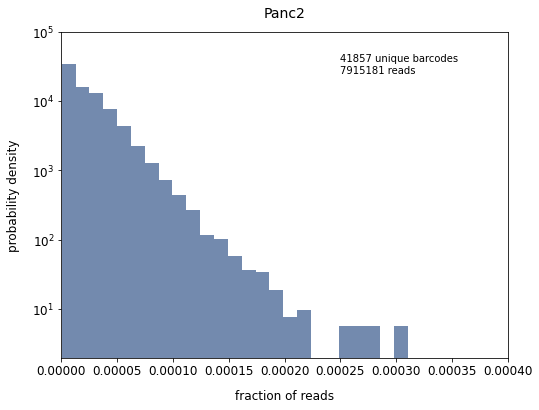

In [425]:
plt.figure(figsize=(8, 6))

plt.hist(bc_fracs_D, density=True, bins=25, color=colors[samples_clIDs['D']], alpha=0.7)
plt.text(0.00025, 25000, str(len(bc_counts_D)) + ' unique barcodes\n' + str(sum(bc_counts_D)) + ' reads')


plt.yscale('log'); plt.minorticks_off()

# plt.yticks([], []);
plt.xticks(fontsize=12);
plt.xlim(0, 0.0004)

plt.yticks(fontsize=12);
plt.ylim(2, 1e5)

plt.ylabel('probability density', fontsize=12, labelpad=12)
plt.xlabel('fraction of reads', fontsize=12, labelpad=12)
plt.title('Panc2', fontsize=14, pad=14)

# plt.savefig('panc2_bc_distr_26.04_log.png', dpi=300, bbox_inches='tight') 